# **Machine Learning for Classification of Exoplanets**
### Sona Davis
### Department of Astronomy, University of Belgrade

**Project Objectives**
  - Access and **preprocess catalog data** from simulated and real exoplanet observations.

   - Use unsupervised learning(**Autoencoders**) for **anomaly detection**
   
   - Compare exoplanet classification of **Random forest on Raw features vs Autoencodered features**

  - Use **Self-Organizing Maps (SOMs)** to cluster exoplanets based on catalog features.

   

Data on which we are performing machine learning algorithms:

### Catalog(Lifesim)

 Lifesim catalog of simulated planetary systems from  LIFEsim Tutorial @ LIFE Science Team , Berlin (25. - 27. September 2023)




Part 1:

#  **Anomaly detection using Autoencoders**

Loading the Lifesim catalog with planetary parameters

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!ls "/content/drive/MyDrive/MASS /Serbiaaa/spectra/catalog.txt"




'/content/drive/MyDrive/MASS /Serbiaaa/spectra/catalog.txt'


In [4]:
import pandas as pd

catalog = pd.read_csv('/content/drive/MyDrive/MASS /Serbiaaa/spectra/catalog.txt', sep="\t")

In [40]:
# Load the catalog

data = catalog.head(len(catalog))
catalog.head(10)

,Planet#,Diameter (km),g (m/s^2),semi-major axis (AU),T star (K),Radius star (m),Mass planet (kg),T planet (K),Gases atmosphere,Abundances,Unit abundances
0,2000,15752.17008,14.127306,0.04124,3250.0,0.291,1.313876e+25,384.81536,"CO2,SO2,H2O,CO,HCl,HF","91.31,110.86,31.34,28.82,0.4,6.3","pct,ppm,ppm,ppm,ppm,ppm"
1,2001,19740.54350,29.341312,0.08553,3250.0,0.291,4.285603e+25,258.49891,"N2,O2,H2O,CO2,O3,CH4","80.42,15.46,1.59,0.21,6.71,4.1","pct,pct,pct,pct,ppm,ppm"
2,2002,8103.65716,5.922827,0.13891,3250.0,0.291,1.457825e+24,172.94177,"N2,O2,H2O,CO2,O3,CH4","76.2,17.04,0.89,0.35,8.21,8.29","pct,pct,pct,pct,ppm,ppm"
3,2005,14793.07974,11.027591,0.10028,3100.0,0.243,9.045072e+24,206.89374,"N2,O2,H2O,CO2,O3,CH4","70.26,13.86,1.87,0.22,8.87,1.6","pct,pct,pct,pct,ppm,ppm"
4,2008,18517.94860,12.067535,0.03614,3000.0,0.149,1.551024e+25,283.40715,"N2,O2,H2O,CO2,O3,CH4","74.66,21.8,1.8,0.09,4.29,9.54","pct,pct,pct,pct,ppm,ppm"
5,2009,15126.53788,21.349622,0.05425,3000.0,0.149,1.830979e+25,223.90489,"N2,O2,H2O,CO2,O3,CH4","81.81,15.66,1.04,0.04,1.93,6.83","pct,pct,pct,pct,ppm,ppm"
6,2018,14691.39858,9.669726,0.02219,3100.0,0.243,7.822663e+24,461.84180,"CO2,SO2,H2O,CO,HCl,HF","91.59,75.2,42.8,60.15,9.12,2.04","pct,ppm,ppm,ppm,ppm,ppm"
7,2019,17255.08898,7.616179,0.03617,3100.0,0.243,8.499350e+24,345.96859,"CO2,SO2,H2O,CO,HCl,HF","93.31,145.55,51.83,35.57,5.18,7.14","pct,ppm,ppm,ppm,ppm,ppm"
8,2020,16325.17782,25.543535,0.05652,3100.0,0.243,2.551591e+25,229.76664,"CO2,SO2,H2O,CO,HCl,HF","93.1,58.58,37.83,58.48,5.91,4.08","pct,ppm,ppm,ppm,ppm,ppm"
9,2026,15932.34196,10.766796,0.12011,3100.0,0.243,1.024377e+25,173.94161,"N2,O2,H2O,CO2,O3,CH4","71.3,14.34,2.8,0.15,9.36,9.13","pct,pct,pct,pct,ppm,ppm"


In [41]:
num_row = len(data)
num_row
# Alternatively, using the .shape attribute:
   #num_rows = data.shape[0]

540

In [42]:
numerical_cols = ['Diameter (km)', 'g (m/s^2)', 'semi-major axis (AU)',
                  'T star (K)', 'Radius star (m)', 'Mass planet (kg)', 'T planet (K)']

In [43]:


# Split abundances
#abun_split = catalog['Abundances'].str.split(',', expand=True)
#abun_split = abun_split.apply(pd.to_numeric)  # convert to float
#abun_split.columns = [f"Abun_{i}" for i in abun_split.columns]

# Combine with numerical columns
#X_numeric = pd.concat([catalog[numerical_cols], abun_split], axis=1)
X_numeric = catalog[numerical_cols]

In [44]:
print(X_numeric)

     Diameter (km)  g (m/s^2)  semi-major axis (AU)  T star (K)  \
0      15752.17008  14.127306               0.04124      3250.0   
1      19740.54350  29.341312               0.08553      3250.0   
2       8103.65716   5.922827               0.13891      3250.0   
3      14793.07974  11.027591               0.10028      3100.0   
4      18517.94860  12.067535               0.03614      3000.0   
..             ...        ...                   ...         ...   
535    19436.51938  14.344080               0.05465      3000.0   
536     8443.23146   2.058262               0.01125      3250.0   
537    13706.18714  16.821600               0.02396      3250.0   
538    10615.36020   7.133554               0.08455      3250.0   
539     6400.68886   5.652458               0.15033      3250.0   

     Radius star (m)  Mass planet (kg)  T planet (K)  
0              0.291      1.313876e+25     384.81536  
1              0.291      4.285603e+25     258.49891  
2              0.291      1.45

**Preprocessing**


In [45]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_numeric)



**Define Autoencoder**


Builds a neural network autoencoder:

- **Encoder** compresses features to a low-dimensional latent space.

- **Decoder** reconstructs the input.

In [46]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

input_dim = X_scaled.shape[1]
input_layer = Input(shape=(input_dim,))
encoded = Dense(128, activation='relu')(input_layer)
encoded = Dense(64, activation='relu')(encoded)
encoded = Dense(32, activation='relu')(encoded)
decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(decoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mse')


**Train the autoencoder**

In [47]:
autoencoder.fit(
   X_scaled, X_scaled,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    shuffle=True
)


Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0963 - val_loss: 0.0324
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0321 - val_loss: 0.0254
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0205 - val_loss: 0.0184
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0170 - val_loss: 0.0148
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0130 - val_loss: 0.0093
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0101 - val_loss: 0.0043
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0055 - val_loss: 0.0029
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0043 - val_loss: 0.0020
Epoch 9/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0028 - val_loss: 0.0016
Epoch 10/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0015 - val_loss: 0.0016
Epoch 11/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0014 - val_loss: 0.0011
Epoch 12/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0011 - val_lo

## **Detect anomalies**

In [48]:
import pandas as pd
import numpy as np
import os

In [124]:
reconstructed = autoencoder.predict(X_scaled)
mse = np.mean((X_scaled - reconstructed)**2, axis=1)

threshold = np.percentile(mse, 90)  # top 10% as anomalies
anomalies =catalog[mse > threshold]

print(f"Detected {len(anomalies)} anomalous planets")
print(anomalies[['Planet#', 'Diameter (km)', 'Mass planet (kg)', 'T planet (K)']])


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Detected 54 anomalous planets
     Planet#  Diameter (km)  Mass planet (kg)  T planet (K)
24      2061    19326.30108      8.497200e+25     293.09324
59      2219    20112.48248      1.830979e+25     397.66056
66      2251    10738.32050      4.854818e+24     245.67391
90      2328    20209.57652      1.685197e+25     273.50360
99      2383    20110.31634      1.457455e+25     278.30047
132     2488    19808.84062      1.024377e+25     175.90515
143     2528     6997.14188      5.499615e+23    1092.47955
149     2549    19699.64168      9.234623e+24     196.11473
151     2554    13467.40206      7.822663e+24     206.37230
155     2567     8624.29528      2.031065e+25     462.25158
159     2580    20276.98170      2.073628e+25     244.13223
171     2639     7219.61720      7.663868e+23    1142.35704
175     2666    19317.25426      1.024377e+25     362.29096
178     2675    20308.32702      2.031065e+25     260.54143
180     2681    19035.78348   

In [199]:
#anomalies

In [202]:
catalog['Radius_Earth'] = catalog['Diameter (km)'] / 12742
anomalies['Radius_Earth'] = anomalies['Diameter (km)'] / 12742  # Earth diameter ≈ 12742 km


/tmp/ipython-input-3194381545.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anomalies['Radius_Earth'] = anomalies['Diameter (km)'] / 12742  # Earth diameter ≈ 12742 km


Plotting **Planet radius vs Mass**

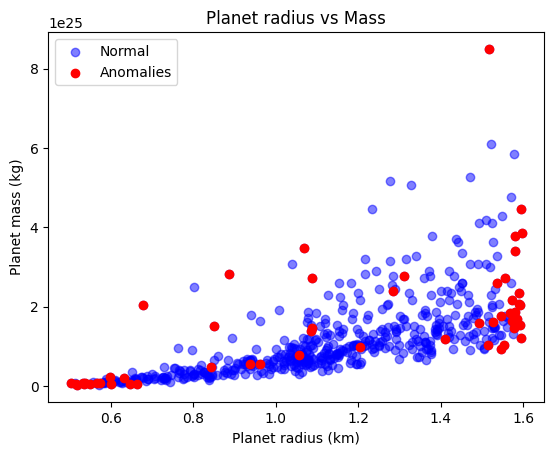

In [205]:
import matplotlib.pyplot as plt

plt.scatter(catalog['Radius_Earth'], catalog['Mass planet (kg)'], alpha=0.5,color='blue', label='Normal')
plt.scatter(anomalies['Radius_Earth'], anomalies['Mass planet (kg)'], color='red', label='Anomalies')
plt.xlabel('Planet radius (km)')
plt.ylabel('Planet mass (kg)')
plt.title('Planet radius vs Mass')
plt.legend()
plt.show()




### **Do these anomalies correspond to known physical types?**

**Exoplanet classifications**
- **Hot Jupiters** : Temp greater than 1000 K, mass similar to Jupiter
- **Mini-Neptunes** : Larger than Earth,smaller than Neptune , Radii between 2 and    4 times Earth radius
- **Super-Earths** : Mass greater than Earth ,less than Uranus or Neptune ,denser,radii less than 2 times Earth Radius

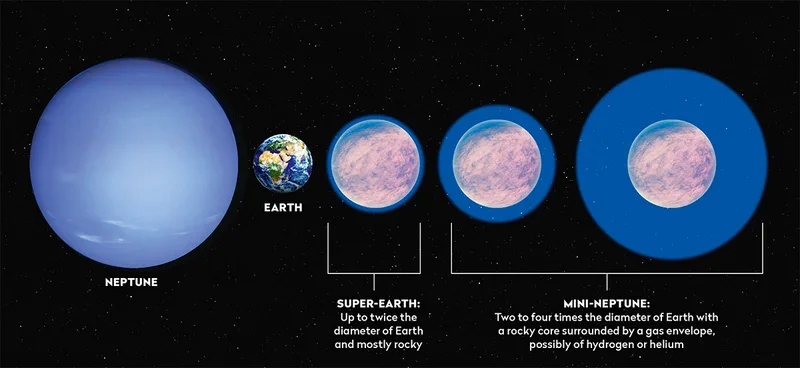

### Calculate densities from mass and radius


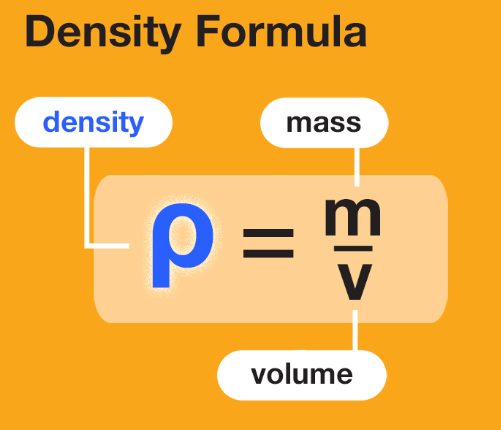



The equation to find density $\rho$ from mass $m$ and volume $V$ is: $ \rho =\frac{m}{V}$

The equation for the volume $V$ of a sphere with a radius $r$ is: $ V=\frac{4}{3}\pi r^{3}$

In [126]:
# Density in g/cm³
anomalies['Density'] = anomalies['Mass planet (kg)'] / ((4/3) * np.pi * (anomalies['Diameter (km)']*1e3/2)**3) / 1000


/tmp/ipython-input-853947142.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anomalies['Density'] = anomalies['Mass planet (kg)'] / ((4/3) * np.pi * (anomalies['Diameter (km)']*1e3/2)**3) / 1000


Density > 5 g/cm³ → likely rocky / super-Earth

Density < 2 g/cm³ → likely gas giants or mini-Neptune

In [168]:

hot_jupiters = anomalies[(anomalies['Radius_Earth'] > 7) & (anomalies['T planet (K)'] > 1000)]
mini_neptunes = anomalies[(anomalies['Radius_Earth'] >= 1.5) & (anomalies['Radius_Earth'] <= 4)]
super_earths = anomalies[(anomalies['Density'] > 5) & (anomalies['Radius_Earth'] < 2)]


/tmp/ipython-input-114980743.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  hot_jupiters.anoamlies = anomalies[(anomalies['Radius_Earth'] > 7) & (anomalies['T planet (K)'] > 1000)]


In [169]:
anomalies['Radius_Earth'] = (anomalies['Diameter (km)'] / 12742)  # Earth's diameter = 12742 km
catalog['Radius_Earth'] = (catalog['Diameter (km)'] / 12742)


/tmp/ipython-input-2795909580.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anomalies['Radius_Earth'] = (anomalies['Diameter (km)'] / 12742)  # Earth's diameter = 12742 km


**Mass vs Radius**

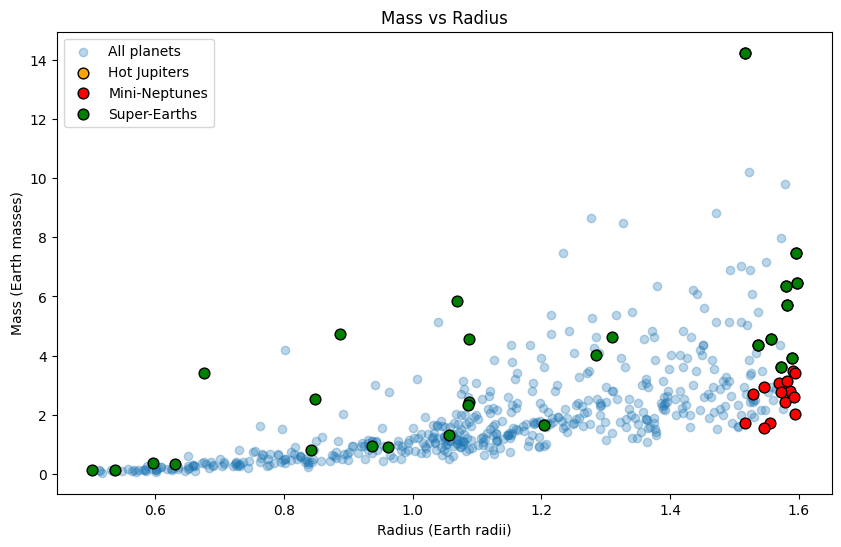

In [174]:
import matplotlib.pyplot as plt

# Assign colors to each type
colors = {
    'Hot Jupiters': 'orange',
    'Mini-Neptunes': 'red',
    'Super-Earths': 'green'
}

plt.figure(figsize=(10,6))

# Background: all planets
plt.scatter(
    catalog['Diameter (km)']/12742,
    catalog['Mass planet (kg)']/5.97e24,
    alpha=0.3,
    label='All planets'
)

# Hot Jupiters
plt.scatter(
    hot_jupiters['Radius_Earth'],
    hot_jupiters['Mass planet (kg)']/5.97e24,
    color=colors['Hot Jupiters'],
    s=60,
    edgecolor='k',
    label='Hot Jupiters'
)

# Mini-Neptunes
plt.scatter(
    mini_neptunes['Radius_Earth'],
    mini_neptunes['Mass planet (kg)']/5.97e24,
    color=colors['Mini-Neptunes'],
    s=60,
    edgecolor='k',
    label='Mini-Neptunes'
)

# Super-Earths
plt.scatter(
    super_earths['Radius_Earth'],
    super_earths['Mass planet (kg)']/5.97e24,
    color=colors['Super-Earths'],
    s=60,
    edgecolor='k',
    label='Super-Earths'
)




#plt.scatter(catalog['Diameter (km)']/12742, catalog['Mass planet (kg)']/5.97e24, alpha=0.5, label='All planets')
#plt.scatter(anomalies['Radius_Earth'], anomalies['Mass planet (kg)']/5.97e24, color='red', label='Anomalies')
plt.xlabel('Radius (Earth radii)')
plt.ylabel('Mass (Earth masses)')
plt.title('Mass vs Radius')
plt.legend()
plt.show()


This gives an immediate visual sense of how “different” the anomalies are compared to the general population, and whether they form clusters

show if the anomalies cluster where Hot Jupiters, Mini-Neptunes, or super-Earths are expected.

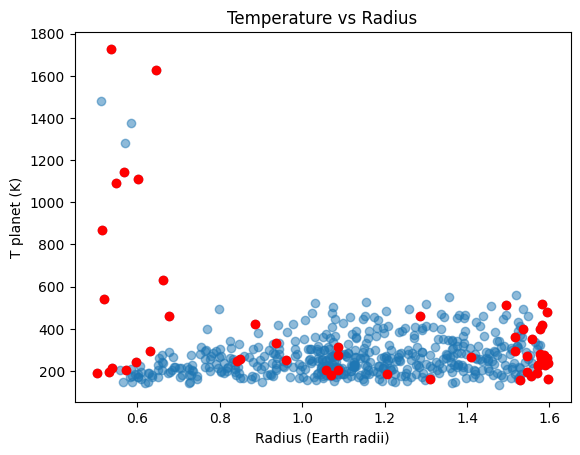

In [130]:
plt.scatter(catalog['Diameter (km)']/12742, catalog['T planet (K)'], alpha=0.5)
plt.scatter(anomalies['Radius_Earth'], anomalies['T planet (K)'], color='red')
plt.xlabel('Radius (Earth radii)')
plt.ylabel('T planet (K)')
plt.title('Temperature vs Radius')
plt.show()


In [131]:
reconstruction = autoencoder.predict(X_scaled)
mse = np.mean(np.square(X_scaled - reconstruction), axis=1)

# Set threshold for anomalies
threshold = np.percentile(mse, 90)  # top 5% as anomalies
anomalies_idx = np.where(mse > threshold)[0]  # indices of anomalies


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [176]:
anomalies_df = catalog.iloc[anomalies_idx].copy()  # catalog info for anomalies


In [177]:
catalog['Planet_Type'] = catalog.apply(classify_planet, axis=1)
y = catalog['Planet_Type']



In [208]:
anomalies_df

,Planet#,Diameter (km),g (m/s^2),semi-major axis (AU),T star (K),Radius star (m),Mass planet (kg),T planet (K),Gases atmosphere,Abundances,Unit abundances,Planet_Type,Radius_Earth,Reconstruction_Error
24,2061,19326.30108,60.696578,0.05053,3100.0,0.243,8.497200e+25,293.09324,"CO2,SO2,H2O,CO,HCl,HF","93.18,133.36,57.43,87.15,3.34,7.32","pct,ppm,ppm,ppm,ppm,ppm",Super-Earth,1.51674,8.313816
57,2209,10223.03402,63.801378,0.15689,3250.0,0.291,2.499216e+25,199.13799,"N2,O2,H2O,CO2,O3,CH4","84.75,10.65,0.81,0.04,2.88,7.48","pct,pct,pct,pct,ppm,ppm",Super-Earth,0.80231,3.635929
118,2439,16286.56956,31.580444,0.10284,3650.0,0.460,3.139725e+25,311.31760,"CO2,SO2,H2O,CO,HCl,HF","97.55,66.57,13.96,53.42,4.8,2.1","pct,ppm,ppm,ppm,ppm,ppm",Super-Earth,1.27818,1.097971
130,2484,16040.39412,20.205209,0.04790,3650.0,0.460,1.948532e+25,494.38419,"CO2,SO2,H2O,CO,HCl,HF","96.05,153.35,90.97,40.09,4.82,1.27","pct,ppm,ppm,ppm,ppm,ppm",Super-Earth,1.25886,6.915728
141,2509,6536.39116,4.785835,0.01386,4540.0,0.737,7.663868e+23,1481.71743,"CO2,N2,Ar,H2O,CO,CH4","95.38,4.28,0.08,3819.05,240.87,24.08","pct,pct,pct,ppm,ppm,ppm",Super-Earth,0.51298,1.957372
148,2548,15728.21512,9.959697,0.63437,5140.0,0.809,9.234623e+24,252.74251,"N2,O2,H2O,CO2,O3,CH4","83.57,11.29,2.07,0.09,4.5,7.8","pct,pct,pct,pct,ppm,ppm",Other,1.23436,3.593349
149,2549,19699.64168,6.348752,0.80021,5140.0,0.809,9.234623e+24,196.11473,"N2,O2,H2O,CO2,O3,CH4","82.0,12.73,1.2,0.06,1.0,1.59","pct,pct,pct,pct,ppm,ppm",Mini-Neptune,1.54604,1.999387
151,2554,13467.40206,11.507283,1.14162,5490.0,0.909,7.822663e+24,206.37230,"N2,O2,H2O,CO2,O3,CH4","88.98,10.22,0.03,0.06,3.02,7.4","pct,pct,pct,pct,ppm,ppm",Super-Earth,1.05693,1.813095
155,2567,8624.29528,72.855521,0.11207,4330.0,0.672,2.031065e+25,462.25158,"CO2,SO2,H2O,CO,HCl,HF","97.77,171.64,17.14,78.05,5.16,1.13","pct,ppm,ppm,ppm,ppm,ppm",Super-Earth,0.67684,2.130399
158,2578,17554.52598,7.358569,0.59231,4540.0,0.737,8.499350e+24,229.91377,"N2,O2,H2O,CO2,O3,CH4","85.72,12.79,1.13,0.02,7.9,9.47","pct,pct,pct,pct,ppm,ppm",Other,1.37769,5.303848


### **Projecting planets into 2D PCA space**
highlighting anomalous planets and classifying them into physically meaningful types like Hot Jupiters, Mini-Neptunes, and Super-Earths.

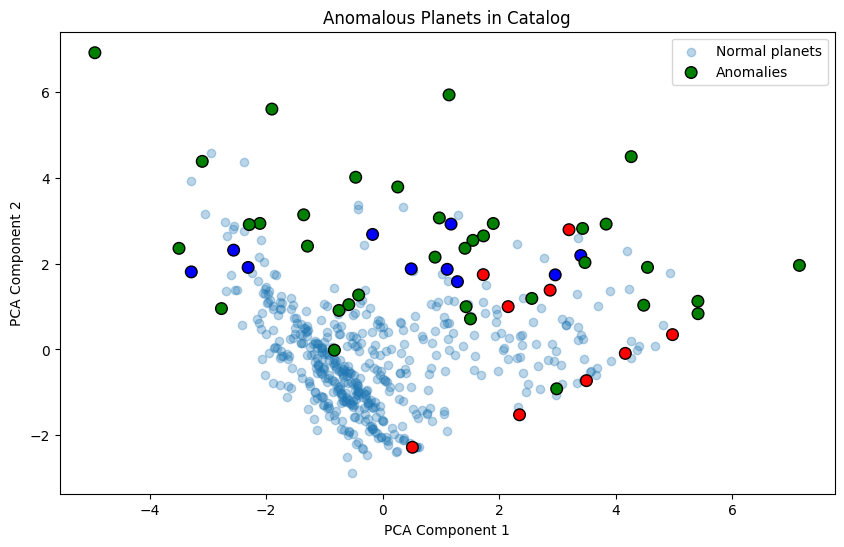

In [179]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA



# anomalies_idx = indices of detected anomalies
# anomalies_df = DataFrame of anomalies with catalog info

# 1️⃣ Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_scaled)

# 2️⃣ Apply PCA (2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 3️⃣ Separate normal planets and anomalies
normal_mask = np.ones(X_scaled.shape[0], dtype=bool)
normal_mask[anomalies_idx] = False

X_normal = X_pca[normal_mask]
X_anomalies = X_pca[anomalies_idx]

# 4️⃣ Classify anomalies into planet types
def classify_planet(row):
    radius = row['Diameter (km)'] / 12742  # Earth radii
    mass = row['Mass planet (kg)'] / 5.972e24  # Earth masses
    temp = row['T planet (K)']
    density = row['Mass planet (kg)'] / ((4/3) * np.pi * (row['Diameter (km)']*1e5/2)**3)

    if radius > 7 and mass > 100  and temp > 1000:
        return 'Hot Jupiter'
    elif 1.5 <= radius <= 4 and mass < 10:
        return 'Mini-Neptune'
    elif radius <= 2 and density > 5:
        return 'Super-Earth'
    elif density > 8:
        return 'Extremely Dense'
    else:
        return 'Other'

#anomalies_df['Planet_Type'] = anomalies_df.apply(classify_planet, axis=1)

# Map colors for planet types
type_colors = {
    'Hot Jupiter': 'orange',
    'Mini-Neptune': 'blue',
    'Super-Earth': 'green',
    'Extremely Dense': 'purple',
    'Other': 'red'
}

anomaly_colors = anomalies_df['Planet_Type'].map(type_colors)


# Plot
plt.figure(figsize=(10,6))
plt.scatter(X_normal[:,0], X_normal[:,1], alpha=0.3, label='Normal planets')
plt.scatter(X_anomalies[:,0], X_anomalies[:,1], color=anomaly_colors, s=70, edgecolor='k', label='Anomalies')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Anomalous Planets in Catalog' )
plt.legend()
plt.show()




*  Gray dots → Normal planets (background cluster)
*   Colored dots with black edges → Anomalies, color-coded by type
*  Position → Where anomalies fall relative to normal planets in reduced PCA space



These are the coordinates of each planet in the new rotated 2D space.

* Component 1 captures the largest source of variation in the data

* Component 2 captures the second-largest source of variation, uncorrelated with Component 1

**Compute reconstruction error**

In [180]:

reconstruction = autoencoder.predict(X_scaled)

# Mean Squared Error per planet (row-wise)
mse = np.mean(np.square(X_scaled - reconstruction), axis=1)


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [181]:
threshold = np.percentile(mse, 90)  # top 10% considered anomalies
anomalies_idx = np.where(mse > threshold)[0]


In [182]:
# anomalies_df = catalog.iloc[anomalies_idx].copy()
# Add reconstruction error column
anomalies_df['Reconstruction_Error'] = mse[anomalies_idx]

# Filter Mini-Neptunes
mini_neptunes = anomalies_df[anomalies_df['Planet_Type'] == 'Mini-Neptune']

# Sort by reconstruction error
mini_neptunes_sorted = mini_neptunes.sort_values(by='Reconstruction_Error', ascending=False)
print(mini_neptunes_sorted[['Planet#','Diameter (km)','Mass planet (kg)','Reconstruction_Error']])


     Planet#  Diameter (km)  Mass planet (kg)  Reconstruction_Error
159     2580    20276.98170      2.073628e+25              3.081096
333     3248    20344.13204      3.863418e+25              3.070369
479     3775    20136.56486      3.784110e+25              2.476244
149     2549    19699.64168      9.234623e+24              1.999387
201     2760    19445.18394      1.551024e+25              1.902329
228     2867    19574.64266      2.605070e+25              1.698166
175     2666    19317.25426      1.024377e+25              1.552034
189     2721    19363.76256      3.012145e+25              1.405508
340     3274    20154.78592      3.411332e+25              1.317991
269     3037    19990.15928      1.830979e+25              1.211470


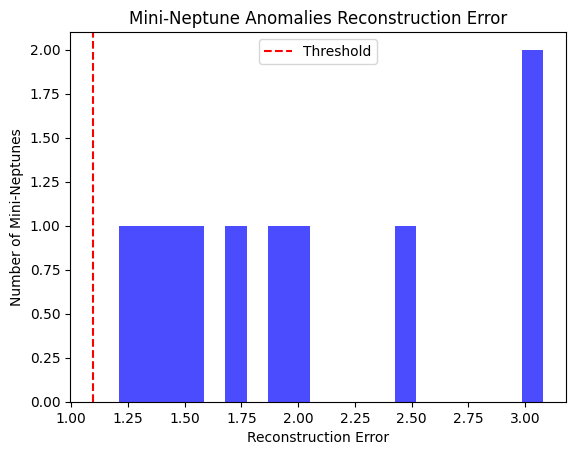

In [183]:
plt.hist(mini_neptunes['Reconstruction_Error'], bins=20, color='blue', alpha=0.7)
plt.axvline(threshold, color='red', linestyle='--', label='Threshold')
plt.xlabel('Reconstruction Error')
plt.ylabel('Number of Mini-Neptunes')
plt.title('Mini-Neptune Anomalies Reconstruction Error')
plt.legend()
plt.show()


## **Random Forest on raw features vs Random Forest on autoencoder-compressed features.**

**RANDOM FOREST on raw data**

In [141]:
#Train Autoencoder and Extract Encoded Features


# Get the encoder part of the autoencoder (bottleneck layer = Dense(32))
encoder = Model(inputs=autoencoder.input, outputs=autoencoder.get_layer(index=3).output)

# Encode catalog+spectra into compressed features
X_encoded = encoder.predict(X_scaled)




#X_encoded = compressed features (dimension reduced)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [142]:
import numpy as np

def classify_planet(row):
    # Convert to Earth units
    radius = row['Diameter (km)'] / 12742        # Earth radii
    mass = row['Mass planet (kg)'] / 5.972e24    # Earth masses
    temp = row['T planet (K)']

    # Compute density in g/cm³
    radius_m = (row['Diameter (km)'] * 1e3) / 2   # radius in meters
    volume = (4/3) * np.pi * (radius_m**3)
    density = row['Mass planet (kg)'] / volume / 1000  # g/cm³

    # Classification rules
    if radius > 7 and mass > 100 and temp > 1000:
        return 'Hot Jupiter'
    elif 1.5 <= radius <= 4 and mass < 10:
        return 'Mini-Neptune'
    elif radius <= 2 and density > 5:
        return 'Super-Earth'
    elif density > 8:
        return 'Extremely Dense'
    else:
        return 'Other'


Prepare Labels

In [143]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Select useful features (you can add more, like semi-major axis, star temp, etc.)
features = ['Diameter (km)', 'Mass planet (kg)', 'T planet (K)']

X = catalog[features]
y = catalog['Planet_Type']

# Encode text labels (Hot Jupiter, Mini-Neptune, etc.) into numbers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


train-test split

In [144]:
from sklearn.model_selection import train_test_split

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)
X_train_enc, X_test_enc, _, _ = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)


Train Random forest

In [184]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Random Forest on raw catalog
rf_raw = RandomForestClassifier(n_estimators=200, random_state=42)
rf_raw.fit(X_train_raw, y_train)
y_pred_raw = rf_raw.predict(X_test_raw)

print("Random Forest on Raw Features")
print(classification_report(y_test, y_pred_raw, target_names=label_encoder.classes_))

# Random Forest on autoencoder-compressed features
rf_enc = RandomForestClassifier(n_estimators=200, random_state=42)
rf_enc.fit(X_train_enc, y_train)
y_pred_enc = rf_enc.predict(X_test_enc)

print("Random Forest on Autoencoder Features")
print(classification_report(y_test, y_pred_enc, target_names=label_encoder.classes_))


Random Forest on Raw Features
              precision    recall  f1-score   support

Mini-Neptune       1.00      1.00      1.00        11
       Other       0.92      0.95      0.94        38
 Super-Earth       0.97      0.95      0.96        59

    accuracy                           0.95       108
   macro avg       0.96      0.97      0.96       108
weighted avg       0.95      0.95      0.95       108

Random Forest on Autoencoder Features
              precision    recall  f1-score   support

Mini-Neptune       0.64      0.82      0.72        11
       Other       0.87      0.87      0.87        38
 Super-Earth       0.95      0.90      0.92        59

    accuracy                           0.88       108
   macro avg       0.82      0.86      0.84       108
weighted avg       0.89      0.88      0.88       108



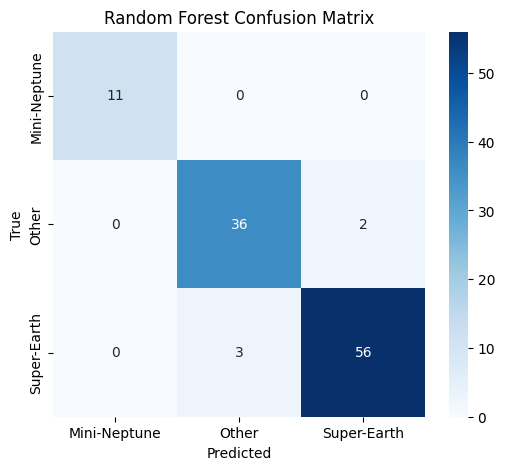

In [185]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
#y_pred = rf.predict(X_test)

# Confusion Matrix
cm1 = confusion_matrix(y_test, y_pred_raw)
plt.figure(figsize=(6, 5))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Random Forest Confusion Matrix")
plt.show()




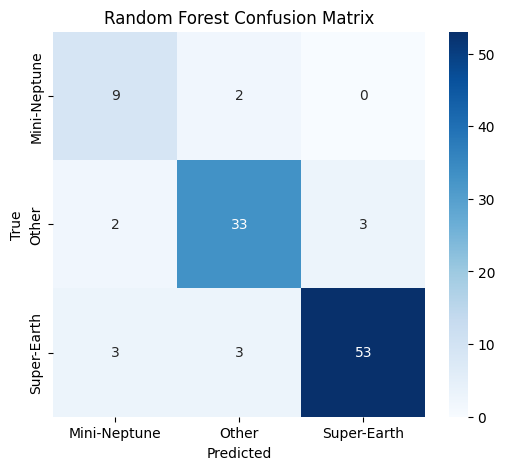

In [186]:
# Confusion Matrix
cm2 = confusion_matrix(y_test, y_pred_enc)
plt.figure(figsize=(6, 5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Random Forest Confusion Matrix")
plt.show()


In [187]:
!pip install minisom

import numpy as np
import pandas as pd
from minisom import MiniSom
import matplotlib.pyplot as plt


In [188]:
# Input dimensions
som_x, som_y = 20, 20   # SOM grid size
input_len = X_scaled.shape[1]

som = MiniSom(som_x, som_y, input_len, sigma=1.0, learning_rate=0.5)
som.random_weights_init(X_scaled)
som.train_random(X_scaled, 1000)  # 1000 iterations

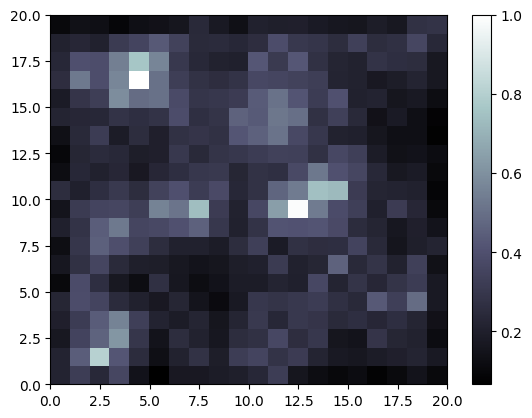

In [189]:
from pylab import bone, pcolor, colorbar, plot, show

bone()
pcolor(som.distance_map().T)  # U-matrix
colorbar()
show()


Darker cells = high distance = anomalies

Light areas = dense clusters (common planet types)

In [190]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_scaled)


In [191]:
# Define SOM size (grid 10x10 is common)
som_size = (5,5)

som = MiniSom(som_size[0], som_size[1],
              X_scaled.shape[1],
              sigma=1.0, learning_rate=0.5,
              random_seed=42)

som.random_weights_init(X_scaled)
som.train_random(X_scaled, 1000)  # 1000 iterations


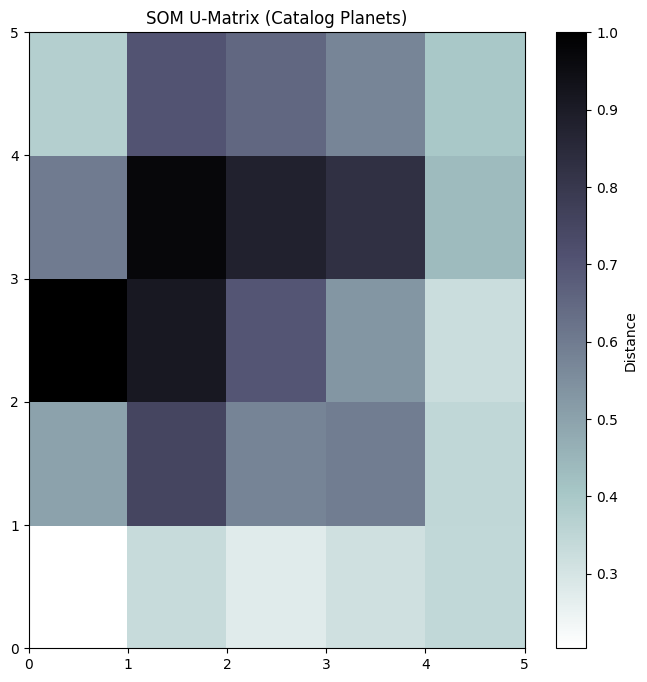

In [192]:
plt.figure(figsize=(8, 8))
plt.pcolor(som.distance_map().T, cmap='bone_r')  # U-matrix
plt.colorbar(label="Distance")
plt.title("SOM U-Matrix (Catalog Planets)")
plt.show()


In [193]:
# Get BMU (best matching unit) for each planet
win_map = {}
for i, x in enumerate(X_scaled):
    w = som.winner(x)
    if w not in win_map:
        win_map[w] = []
    win_map[w].append(i)

# Calculate quantization error (distance to BMU)
errors = np.array([np.linalg.norm(x - som.get_weights()[som.winner(x)])
                   for x in X_scaled])

# Threshold = mean + 2*std
#threshold = errors.mean() + 2*errors.std()
threshold = np.percentile(errors, 90)

anomalies_idx = np.where(errors > threshold)[0]

anomalies_som= catalog.iloc[anomalies_idx]
print("Detected anomalies:", anomalies_som)


Detected anomalies:      Planet#  Diameter (km)  g (m/s^2)  semi-major axis (AU)  T star (K)  \
24      2061    19326.30108  60.696578               0.05053      3100.0   
57      2209    10223.03402  63.801378               0.15689      3250.0   
118     2439    16286.56956  31.580444               0.10284      3650.0   
130     2484    16040.39412  20.205209               0.04790      3650.0   
141     2509     6536.39116   4.785835               0.01386      4540.0   
148     2548    15728.21512   9.959697               0.63437      5140.0   
149     2549    19699.64168   6.348752               0.80021      5140.0   
151     2554    13467.40206  11.507283               1.14162      5490.0   
155     2567     8624.29528  72.855521               0.11207      4330.0   
158     2578    17554.52598   7.358569               0.59231      4540.0   
159     2580    20276.98170  13.455815               0.29446      4330.0   
160     2595    14698.15184  32.172126               0.49543      45

In [194]:
anomalies_table = anomalies_som[['Planet#', 'Diameter (km)', 'Mass planet (kg)', 'T planet (K)','Planet_Type']]
anomalies_table


,Planet#,Diameter (km),Mass planet (kg),T planet (K),Planet_Type
24,2061,19326.30108,8.497200e+25,293.09324,Super-Earth
57,2209,10223.03402,2.499216e+25,199.13799,Super-Earth
118,2439,16286.56956,3.139725e+25,311.31760,Super-Earth
130,2484,16040.39412,1.948532e+25,494.38419,Super-Earth
141,2509,6536.39116,7.663868e+23,1481.71743,Super-Earth
148,2548,15728.21512,9.234623e+24,252.74251,Other
149,2549,19699.64168,9.234623e+24,196.11473,Mini-Neptune
151,2554,13467.40206,7.822663e+24,206.37230,Super-Earth
155,2567,8624.29528,2.031065e+25,462.25158,Super-Earth
158,2578,17554.52598,8.499350e+24,229.91377,Other


In [195]:
set_auto = set(anomalies['Planet#'])
set_som  = set(anomalies_som['Planet#'])

overlap = set_auto & set_som
only_auto = set_auto - set_som
only_som = set_som - set_auto

print("Overlap anomalies:", overlap)
print("Only autoencoder anomalies:", only_auto)
print("Only SOM anomalies:", only_som)



Overlap anomalies: {2819, 2567, 2061, 2704, 2580, 3992, 2719, 2735, 3119, 3248, 2867, 3647, 3775, 3913, 3274, 3037, 2666, 3693, 3953, 2549, 2681, 2554}
Only autoencoder anomalies: {3078, 2954, 3467, 3210, 3088, 2837, 2328, 3996, 3100, 3752, 3754, 2219, 2863, 3124, 2743, 2488, 3896, 3911, 2251, 3148, 3661, 2383, 2639, 3926, 3929, 3421, 2528, 3690, 3822, 2799, 2675, 3831}
Only SOM anomalies: {3073, 2693, 2439, 2952, 2829, 2578, 2968, 3225, 2209, 2721, 2595, 2849, 2982, 2738, 2866, 2484, 3006, 2751, 2760, 2635, 2509, 2903, 3038, 3040, 3171, 2661, 2668, 2796, 2802, 3187, 2548, 3071}


In [196]:
print("Number of anomalies detected by SOM:", len(anomalies_som))


Number of anomalies detected by SOM: 54


In [197]:
print("Number of anomalies detected by Autoencoders:", len(anomalies))


Number of anomalies detected by Autoencoders: 54
